In [1]:
import pickle
import scipy
import abtem
import numpy as np

from abtem.waves import Probe
from abtem.core.energy import energy2wavelength
from matplotlib import pyplot as plt
from abtem.core.energy import energy2sigma
from abtem.potentials.iam import PotentialArray
from abtem import PixelatedDetector
from abtem.scan import GridScan
from quantem.core.visualization import show_2d


VOLT_INTEGRAL_TO_PHASE_FACT = (
    scipy.constants.e /
    (scipy.constants.hbar * 0.45 * scipy.constants.c)  # if acc is 60e3
) # [1/(Vm)]

ACC_VOLTAGE     = 60e3  # eV
PROBE_SEMIANGLE = 30    # mrad
PROBE_DEFOCUS   = 0     # Å
SCAN_STEP_SIZE  = 0.15  # Å

def get_measurement(
    phase_image,
    dx,
    dy,
    acc_voltage=ACC_VOLTAGE,
    probe_semiangle=PROBE_SEMIANGLE,
    probe_defocus=PROBE_DEFOCUS,
    scan_step_size=SCAN_STEP_SIZE,
    pad_frac=None,
    plot=False,
):
    sigma = float(energy2sigma(acc_voltage))
    V = phase_image / (sigma)
    V_slices = V[np.newaxis, :, :].astype(np.float32)

    potential = PotentialArray(
        array=V_slices,
        slice_thickness=1,
        sampling=(dx, dy),
    )

    # create probe and scan
    probe = Probe(
        energy=acc_voltage,
        semiangle_cutoff=probe_semiangle, 
        defocus=probe_defocus
    )

    # probe.grid.match(potential)
    probe.match_grid(potential)
    probe.show(cbar=True)

    if pad_frac is None:
        scan = GridScan(
            start=(0.0, 0.0),
            end=potential.extent,
            potential=potential,
            sampling=scan_step_size,
            endpoint=True,
        )
    else:
        scan = GridScan(
            start=(pad_frac, pad_frac),
            end=(1-pad_frac, 1-pad_frac),
            fractional=True,
            potential=potential,
            sampling=scan_step_size,
            endpoint=True,
        )

    if plot:
        fig, ax = plt.subplots()
        potential.show(ax=ax)
        scan.add_to_plot(ax)
        plt.show()
    
    detector = PixelatedDetector(max_angle='valid')

    measurement = probe.scan(potential, scan=scan, detectors=detector)
    measurement.compute()   # typically dims: (Nx_scan, Ny_scan, Nkx, Nky)

    if plot:
        show_2d(measurement.array.mean((0,1)), cbar=True, cmap='turbo', vmax=0.000001)

    return measurement



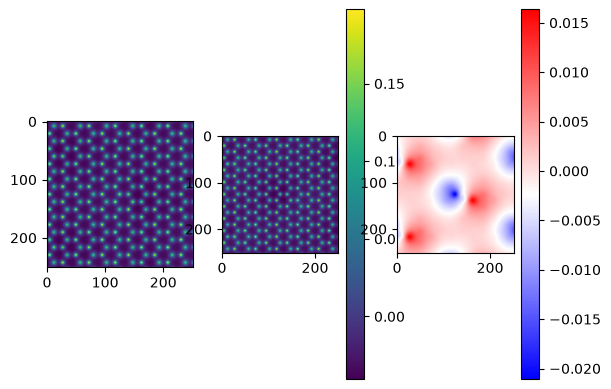

In [3]:
with open('bcenters_base_excited_phases_wide_fov.pkl', 'rb') as f:
    data = pickle.load(f)

base_phase = data['base']
excited_phase = data['excited']
x = data['x']
y = data['y']

dx = x[1] - x[0]
dy = y[1] - y[0]

from matplotlib import pyplot as plt
plt.subplot(1,3,1)
plt.imshow(base_phase)

plt.subplot(1,3,2)
plt.imshow(excited_phase)
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(excited_phase - base_phase, cmap='bwr')
plt.colorbar()

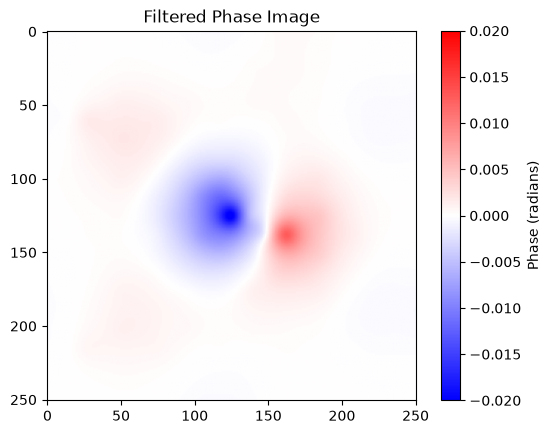

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate phase difference
diff_phase = excited_phase - base_phase

# 2. Generate a 2D Hamming filter matching the shape of your image
# We take the outer product of a vertical window and a horizontal window
window_y = np.hamming(diff_phase.shape[0])
window_x = np.hamming(diff_phase.shape[1])
humming_filter = np.outer(window_y, window_x)

# 3. Apply the filter to the data
filtered_diff_phase = diff_phase * humming_filter

# 4. Plot after Hamming filter
plt.imshow(filtered_diff_phase, cmap='bwr', vmin=-0.02, vmax=0.02)
plt.colorbar(label='Phase (radians)')
plt.title('Filtered Phase Image')
plt.show()


In [5]:
excited_phase = base_phase + filtered_diff_phase

In [6]:
ACC_VOLTAGE     = 60e3   # eV
PROBE_SEMIANGLE = 20     # mrad
PROBE_DEFOCUS   = 30    # Å
SCAN_STEP_SIZE  = 0.15    # Å

from stem_utils import (
    ptycho_wrapper,
    generate_datacube
)

def generate_merged_scan(im1, im2, x=x, y=y, dose=None, dp_trim=65, normalize=True):
    meas1 = generate_datacube(
        im1, 
        x, y,
        acc_voltage=ACC_VOLTAGE, 
        probe_semiangle=PROBE_SEMIANGLE,
        probe_defocus=PROBE_DEFOCUS, 
        scan_step_size=SCAN_STEP_SIZE
    )
    meas2 = generate_datacube(
        im2, 
        x, y,
        acc_voltage=ACC_VOLTAGE, 
        probe_semiangle=PROBE_SEMIANGLE,
        probe_defocus=PROBE_DEFOCUS, 
        scan_step_size=SCAN_STEP_SIZE
    )

    if dose is not None:
        meas1 = meas1.poisson_noise(dose)
        meas2 = meas2.poisson_noise(dose)

    dcube1 = np.array(meas1.array)[:,:,dp_trim:-dp_trim,dp_trim:-dp_trim]
    dcube2 = np.array(meas2.array)[:,:,dp_trim:-dp_trim,dp_trim:-dp_trim]

    # create the cheker-board mask
    scan_mask = np.zeros(dcube2.shape[:2], dtype=np.uint8)
    x_i = np.arange(scan_mask.shape[0])
    y_i = np.arange(scan_mask.shape[1])
    for i in x_i:
        for j in y_i:
            if (i + j) % 2 == 0:
                scan_mask[i, j] = 1
    merged_scan = np.array(dcube1)
    merged_scan[scan_mask==1,:,:] = np.array(dcube2)[scan_mask==1,:,:]

    if normalize:
        for i in range(merged_scan.shape[0]):
            for j in range(merged_scan.shape[1]):
                merged_scan[i,j,:,:] = merged_scan[i,j,:,:] / merged_scan[i,j,:,:].sum()
    return merged_scan, scan_mask

In [7]:
from quantem.core import config
from quantem.core.datastructures import Dataset4dstem
from quantem.core.visualization.visualization import show_2d
from quantem.diffractive_imaging.dataset_models import PtychographyDatasetRaster
from quantem.diffractive_imaging.detector_models import DetectorPixelated
from quantem.diffractive_imaging.object_models import ObjectDIP, ObjectPixelated
from quantem.diffractive_imaging.probe_models import ProbePixelated
from quantem.diffractive_imaging.ptychography import Ptychography
from quantem.core.utils.diffractive_imaging_utils import fit_probe_circle
from quantem.diffractive_imaging.object_models import ObjectMultiplexed
import torch

def mixed_obj_ptycho_wrapper(
    dcube,
    scan_mask,
    # opt_params
    obj_lr=1e-3,
    probe_lr=1e-5,
    tv_weight=1,
    tv_channel_diff=0,
    channel_diff_sparcity=10,
    num_iters=25,
    batch_size=256,
    obj_padding=16,
    plot=True,
    return_extra=True,
):
    opt_params = { # except type, all args are passed to the optimizer (of type type)
        "object": {
            "type": "adam", 
            "lr": obj_lr
        },
        "probe": {
            "type": "adam", 
            "lr": probe_lr, 
        },
    }
    scheduler_params = {
        "object": { ## scheduler kwargs are passed to the scheduler (of type type)
            "type": "plateau", ## i like plateau for many cases
            # "type": "exp",
            # "factor": 9e-2,
        },
        "probe": {
            "type": "plateau",
        },
    }
    constraints = {
        "object": {
            "tv_weight_xy": tv_weight, ## these are mostly the defaults 
            "tv_channel_diff": tv_channel_diff,
            "channel_diff_sparcity": channel_diff_sparcity,
            "fix_potential_baseline": False,
            "identical_slices": True, ## default for this is False 
            "apply_fov_mask": False,
        },
        "probe": {
            "center_probe": False,
            "orthogonalize_probe": True,
        },
        "dataset":{
            "descan_tv_weight": 0,
            "descan_shifts_constant": False, 
        }
    }

    dset = Dataset4dstem.from_array(
        dcube,
        name='merged_scan',
        sampling=(SCAN_STEP_SIZE, SCAN_STEP_SIZE, 1, 1),
        units=("A", "A", "pixels", "pixels")
    )
    probe_qy0, probe_qx0, probe_R = fit_probe_circle(dset.dp_mean.array, show=False)
    dset.sampling[2] = PROBE_SEMIANGLE / probe_R
    dset.sampling[3] = PROBE_SEMIANGLE / probe_R
    dset.units[2:] = ["mrad", "mrad"]
    probe_R = PROBE_SEMIANGLE / dset.sampling[2]

    pdset = PtychographyDatasetRaster.from_dataset4dstem(dset)
    pdset.preprocess(
        com_fit_function="constant",
        plot_rotation=False,
        plot_com=False,
        probe_energy=ACC_VOLTAGE,
        force_com_rotation=0, 
        force_com_transpose=False,
    )    

    probe_params = {
        "energy" : ACC_VOLTAGE,
        "defocus" : PROBE_DEFOCUS,
        "semiangle_cutoff" : PROBE_SEMIANGLE, 
    }
    detector_model = DetectorPixelated() 

    # Set up ptychography model for excited state
    probe_model = ProbePixelated.from_params(
        num_probes=1,
        probe_params=probe_params,
    )
    obj_model = ObjectMultiplexed.from_uniform(
        num_slices=1, 
        slice_thicknesses=1,
        obj_type='pure_phase',
        num_channels=2,
        patches_mask=torch.tensor(scan_mask)
    )
    ptycho = Ptychography.from_models(
        dset=pdset,
        obj_model=obj_model,
        probe_model=probe_model,
        detector_model=detector_model,
        device='cuda',
    )

    ptycho.preprocess( 
        obj_padding_px=(obj_padding, obj_padding),
        batch_size=batch_size,
    )
    ptycho.reconstruct(
        num_iters=num_iters,
        reset=True,
        autograd=True, 
        device='cuda',
        constraints=constraints, 
        optimizer_params=opt_params,
        scheduler_params=scheduler_params,
        batch_size=batch_size,
        multichannel_mode=True,
    ) # .visualize()

    recon_off = np.angle(
        ptycho.obj_model.obj[
            0,0,obj_padding:-obj_padding,obj_padding:-obj_padding
            ].cpu().detach().cpu().numpy())
    recon_on = np.angle(
        ptycho.obj_model.obj[
            1,0,obj_padding:-obj_padding,obj_padding:-obj_padding
            ].cpu().detach().cpu().numpy())

    if not plot:
        return recon_off, recon_on
    
    ptycho.plot_losses()
    
    diff = recon_on - recon_off
    diff_extent = np.max(np.abs(diff))
    plt.figure()
    plt.subplot(2,1,1)
    plt.imshow(recon_off, cmap='gray')
    plt.colorbar()
    plt.subplot(2,1,2)
    plt.imshow(diff, cmap='seismic', vmin=-diff_extent, vmax=diff_extent)
    plt.colorbar()
    plt.show()

    if return_extra:
        return recon_off, recon_on, ptycho
    return recon_off, recon_on

In [21]:
# unconstaint, infinite dose 
scan, scan_mask = generate_merged_scan(
    base_phase, 
    excited_phase, 
    dose=None,
    dp_trim=40,
)


tasks:   2%|1         | 2/123 [00:01<01:51,  1.09it/s]

tasks:   2%|1         | 2/123 [00:01<01:45,  1.15it/s]

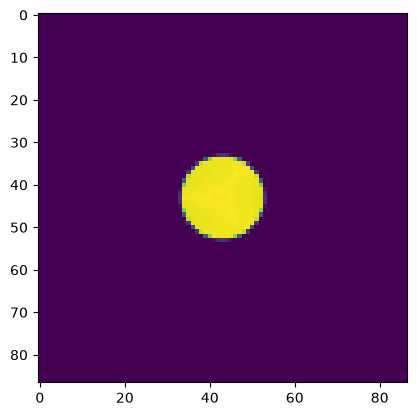

In [22]:
plt.imshow(scan[0,0,...])

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

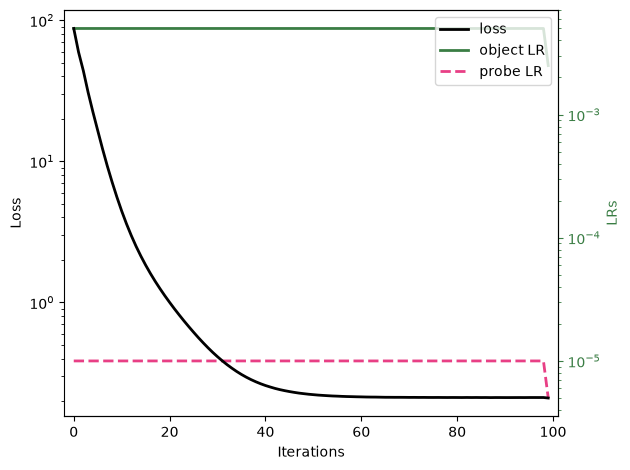

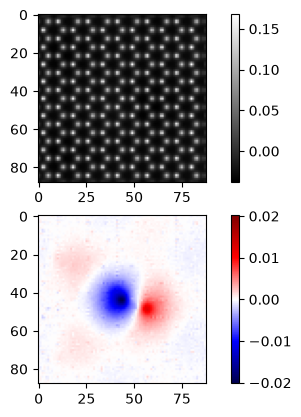

In [24]:
recon_off, recon_on, ptycho = mixed_obj_ptycho_wrapper(
    dcube=scan,
    scan_mask=scan_mask,
    num_iters=100,
    tv_channel_diff=0.0,
    tv_weight=15.0,
    channel_diff_sparcity=0.0,
    obj_lr=5e-3,
    return_extra=True,
    batch_size=2**12,
    obj_padding=64
)


(np.float64(-0.5), np.float64(250.5), np.float64(250.5), np.float64(-0.5))

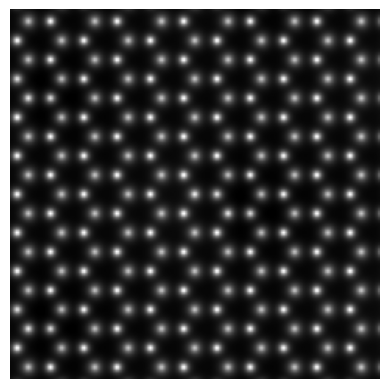

In [44]:
plt.imshow(base_phase, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(250.5), np.float64(250.5), np.float64(-0.5))

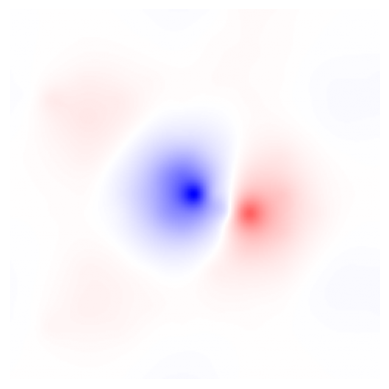

In [8]:
diff = excited_phase - base_phase
diff_color_extent = np.max(np.abs(diff))
plt.imshow(diff, cmap='bwr', vmin=-diff_color_extent, vmax=diff_color_extent)
plt.axis('off')

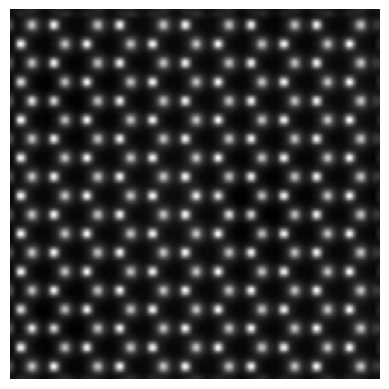

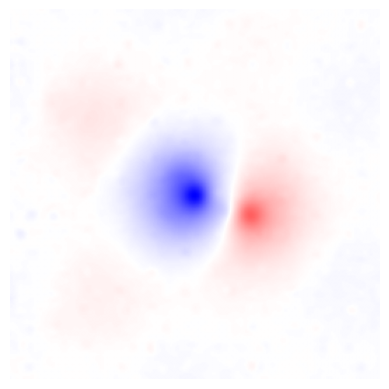

In [47]:
from scipy.ndimage import zoom, gaussian_filter

recon_off_rescaled = zoom(recon_off, 3, order=3)
recon_on_rescaled = zoom(recon_on, 3, order=3)
excitation = recon_on_rescaled - recon_off_rescaled
plt.figure()
plt.imshow(recon_off_rescaled, cmap='gray')
plt.axis('off')
plt.show()
plt.figure()
ex_filtered = gaussian_filter(excitation, sigma=2)
ex_color_extent = np.abs(ex_filtered).max()
plt.imshow(ex_filtered, cmap='bwr', vmin=-ex_color_extent, vmax=ex_color_extent)
plt.axis('off')
plt.show()


In [9]:
# High-dose
scan, scan_mask = generate_merged_scan(
    base_phase, 
    excited_phase, 
    dose=1e6,
    dp_trim=40,
)


tasks:   2%|1         | 2/123 [00:02<02:49,  1.40s/it]

tasks:   2%|1         | 2/123 [00:01<01:50,  1.10it/s]

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

/workspace/quantem_light_enhanced/quantem/src/quantem/diffractive_imaging/object_models.py:1289: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/Copy.cpp:307.)
  post_constraint_obj[ch] = self.apply_hard_constraints(


  0%|          | 0/100 [00:00<?, ?it/s]

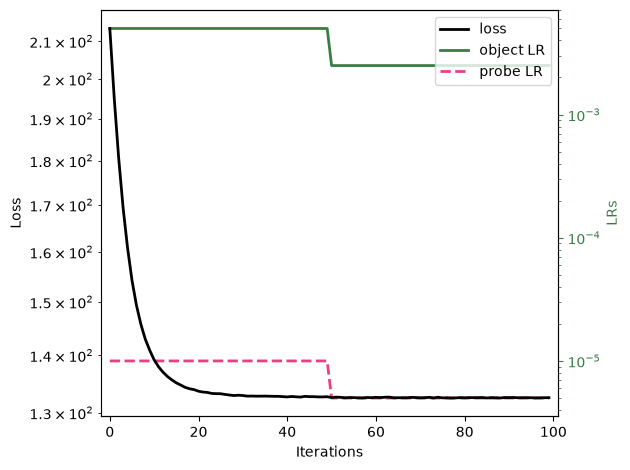

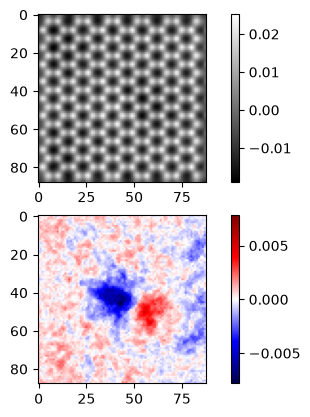

In [ ]:
recon_off, recon_on, ptycho = mixed_obj_ptycho_wrapper(
    dcube=scan,
    scan_mask=scan_mask,
    num_iters=100,
    tv_channel_diff=200,
    tv_weight=0,
    channel_diff_sparcity=0,
    obj_lr=5e-3,
    return_extra=True,
    batch_size=2**12,
    obj_padding=64
)


Running with tv_channel_diff=0.0, sparcity=0.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

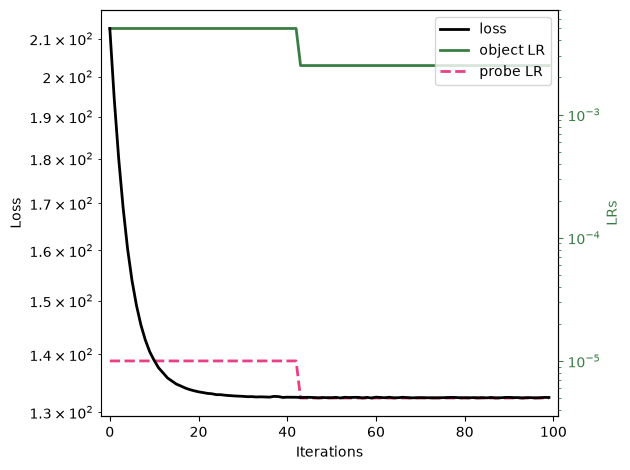

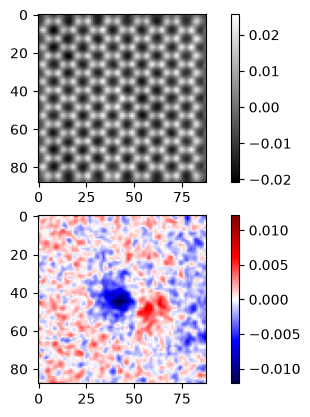

Running with tv_channel_diff=0.0, sparcity=10
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

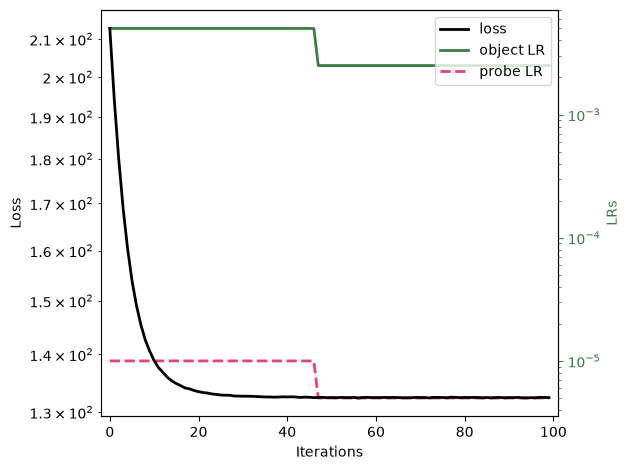

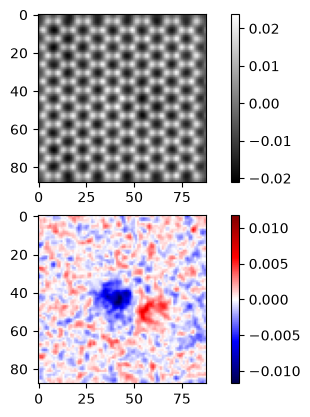

Running with tv_channel_diff=0.0, sparcity=50
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

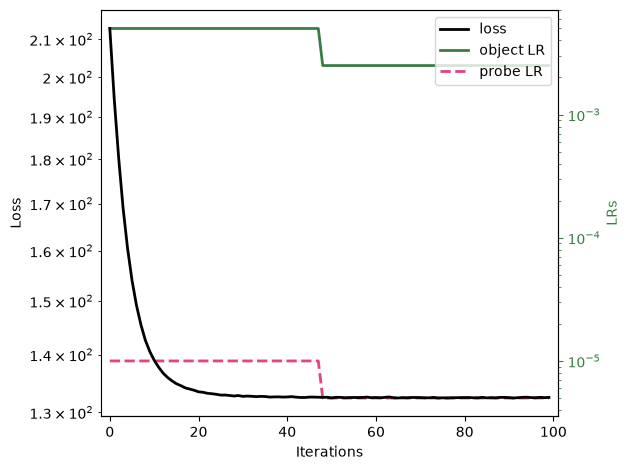

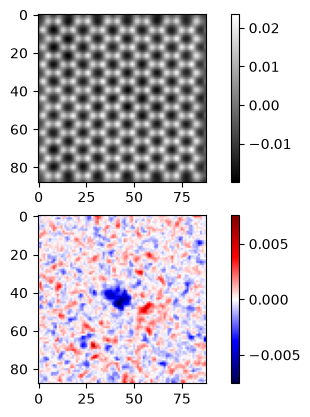

Running with tv_channel_diff=0.0, sparcity=100
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

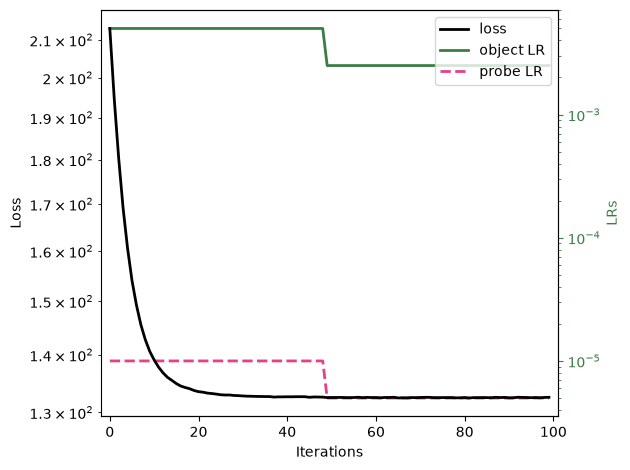

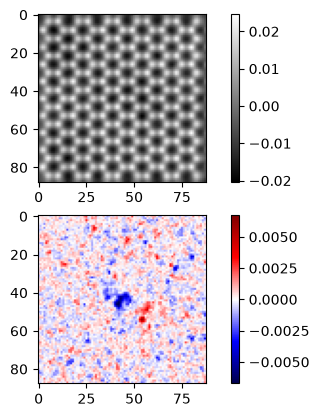

Running with tv_channel_diff=0.0, sparcity=200
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
for tv_channel_diff in [0.0, 100.0, 200, 300, 500]:
    for sparcity in [0.0, 10, 50, 100, 200, 300]:
        print(f"Running with tv_channel_diff={tv_channel_diff}, sparcity={sparcity}")
        recon_off, recon_on, ptycho = mixed_obj_ptycho_wrapper(
            dcube=scan,
            scan_mask=scan_mask,
            num_iters=100,
            tv_channel_diff=tv_channel_diff,
            tv_weight=0,
            channel_diff_sparcity=sparcity,
            obj_lr=5e-3,
            return_extra=True,
            batch_size=2**12,
            obj_padding=64
        )


In [ ]:
# High-dose
scan, scan_mask = generate_merged_scan(
    base_phase, 
    excited_phase, 
    dose=1e5,
    dp_trim=40,
)


tasks:   2%|1         | 2/123 [00:02<02:02,  1.01s/it]

tasks:   2%|1         | 2/123 [00:01<01:44,  1.16it/s]

Running with tv_channel_diff=0.0, sparcity=0.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

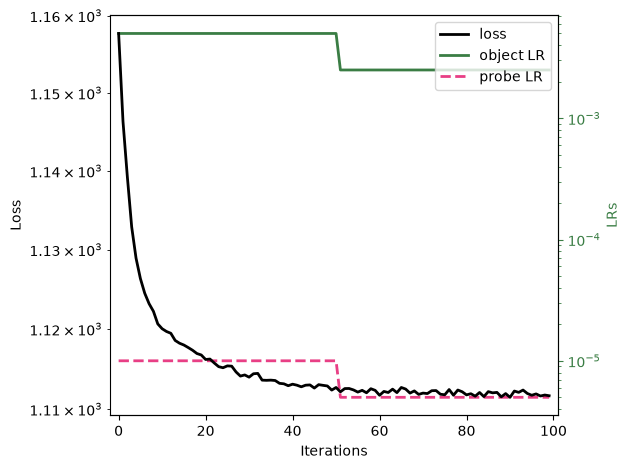

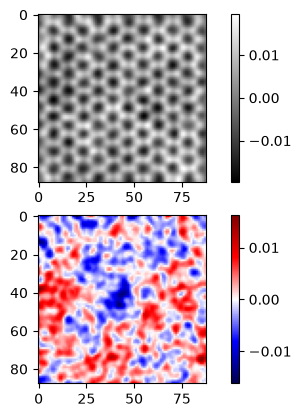

Running with tv_channel_diff=0.0, sparcity=1.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

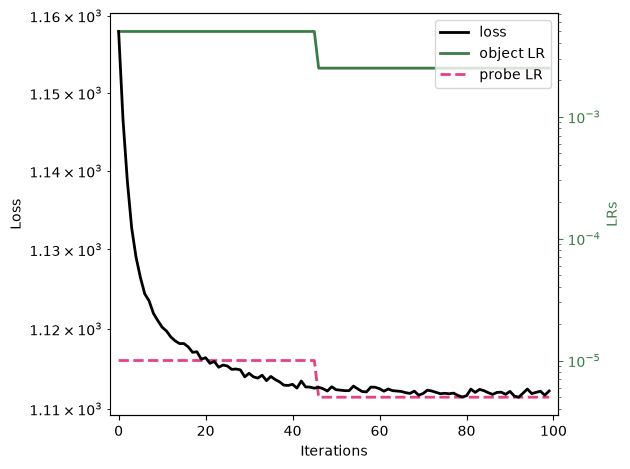

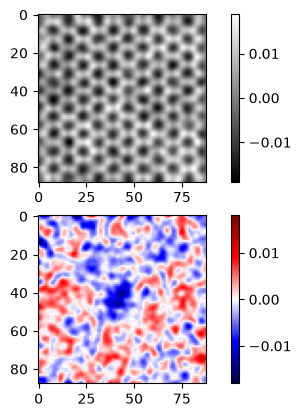

Running with tv_channel_diff=0.0, sparcity=5.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

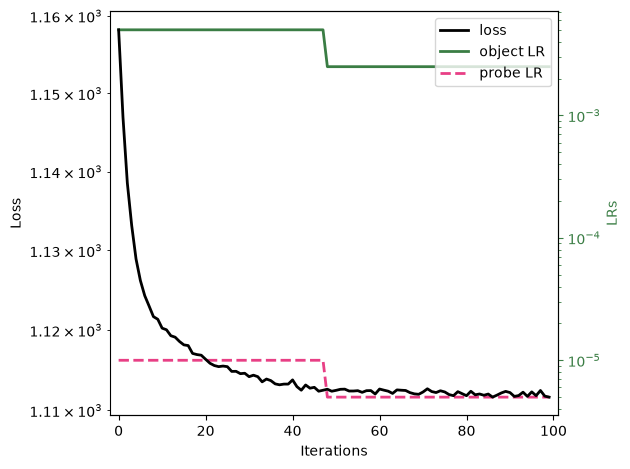

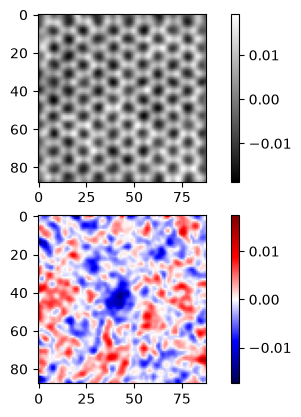

Running with tv_channel_diff=0.0, sparcity=10.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

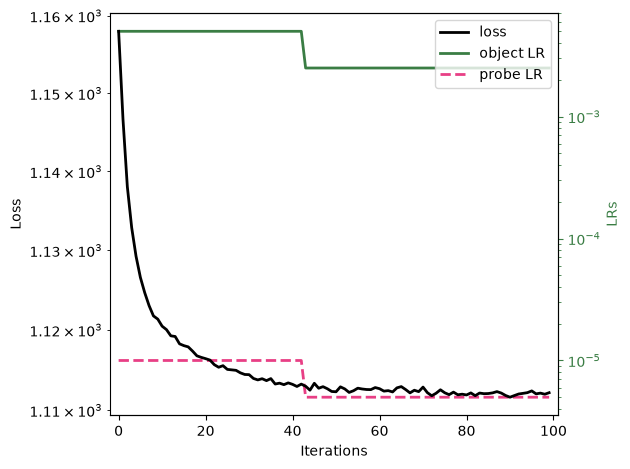

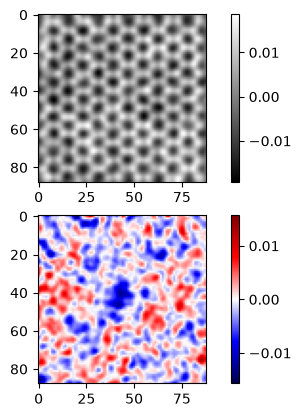

Running with tv_channel_diff=0.0, sparcity=20
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

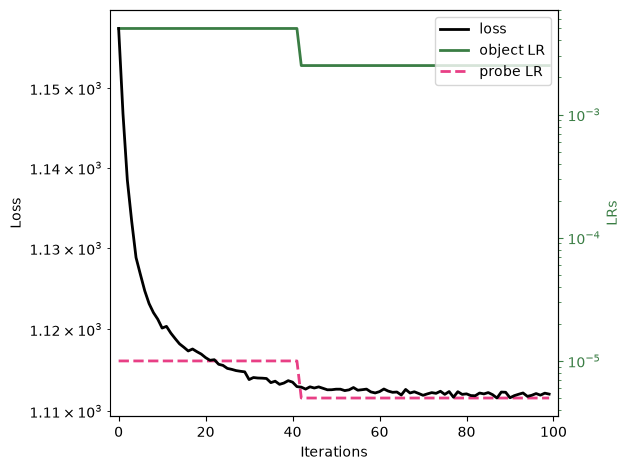

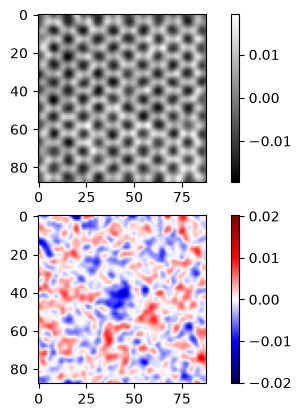

Running with tv_channel_diff=10, sparcity=0.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

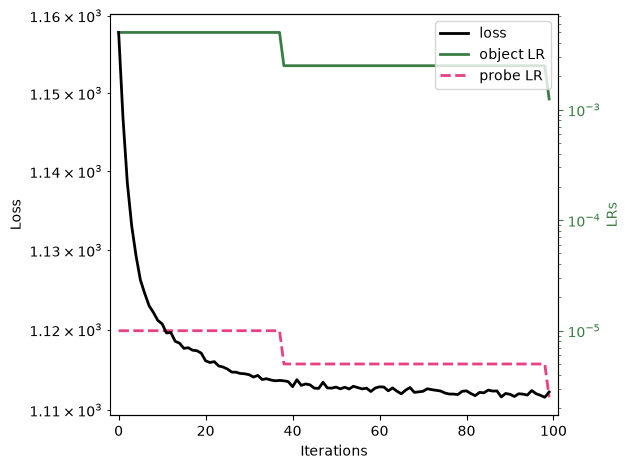

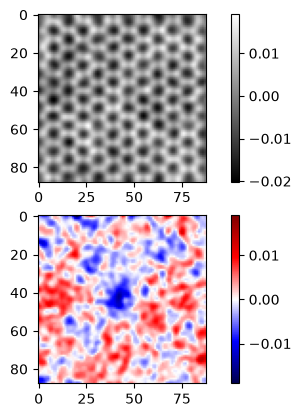

Running with tv_channel_diff=10, sparcity=1.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

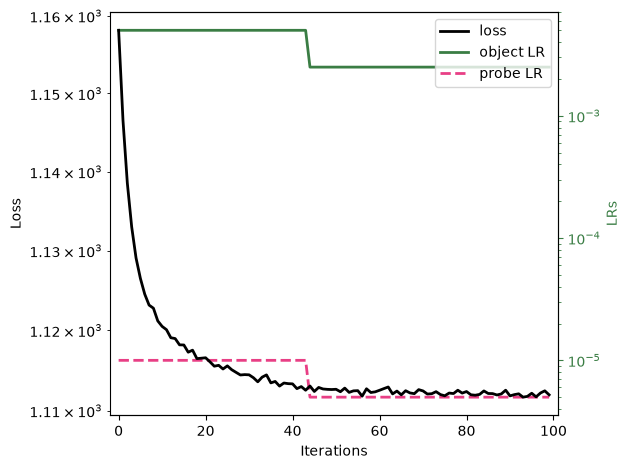

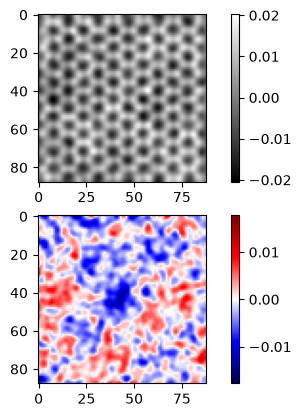

Running with tv_channel_diff=10, sparcity=5.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

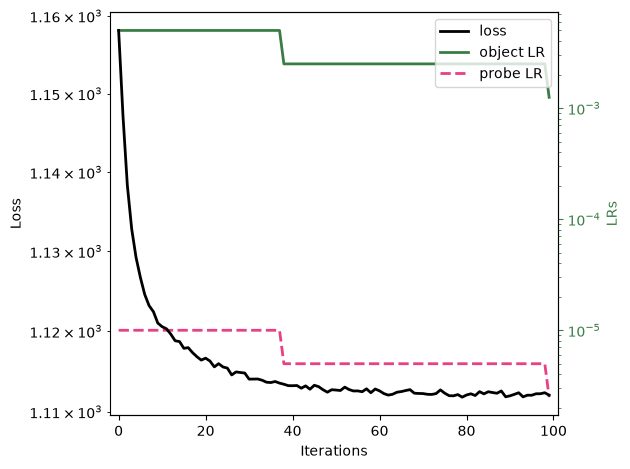

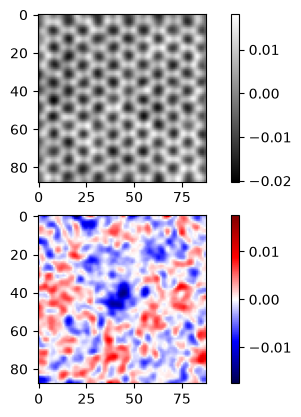

Running with tv_channel_diff=10, sparcity=10.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

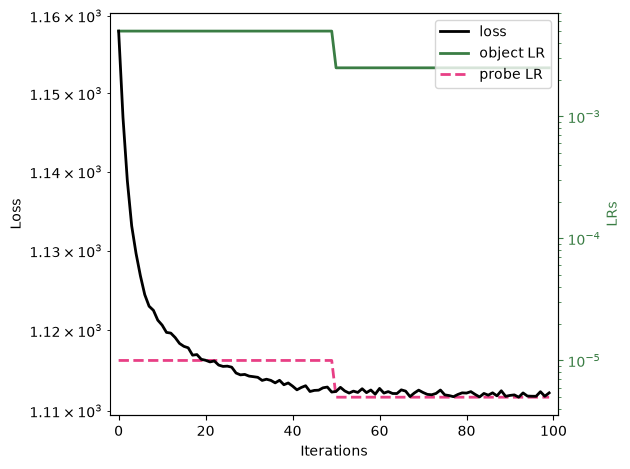

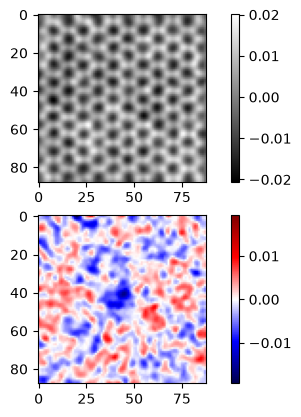

Running with tv_channel_diff=10, sparcity=20
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

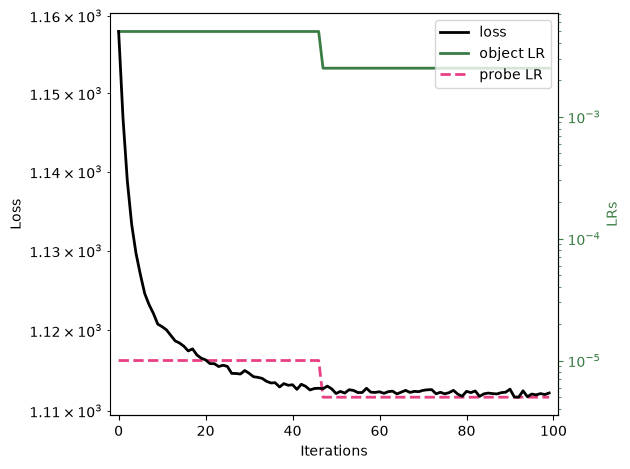

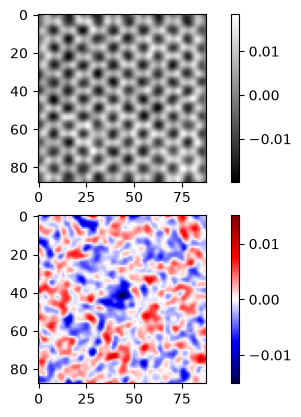

Running with tv_channel_diff=100.0, sparcity=0.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

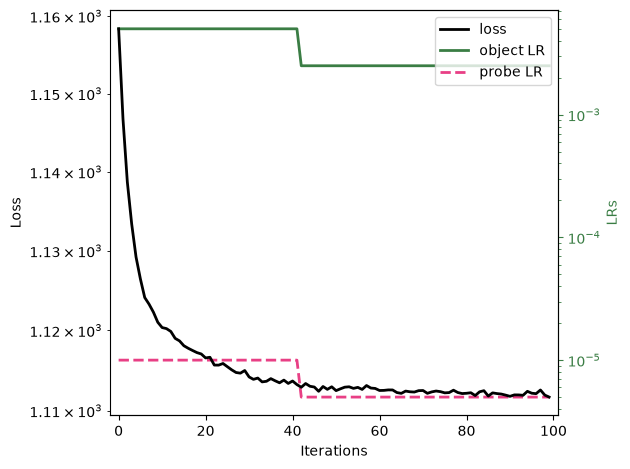

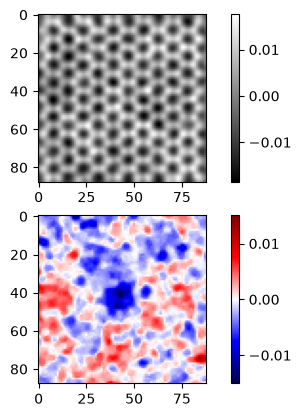

Running with tv_channel_diff=100.0, sparcity=1.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

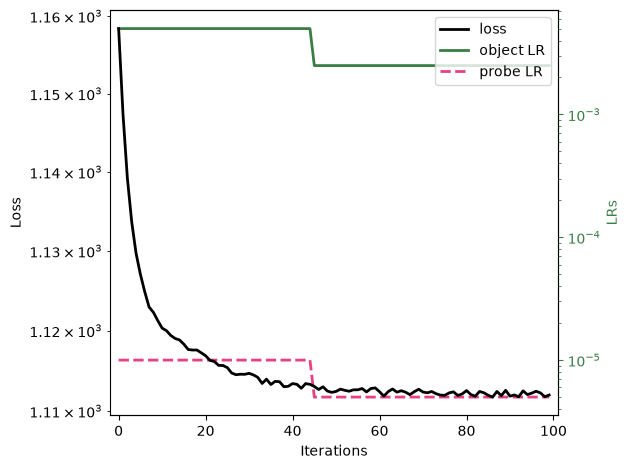

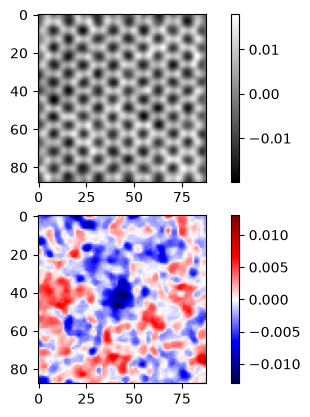

Running with tv_channel_diff=100.0, sparcity=5.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

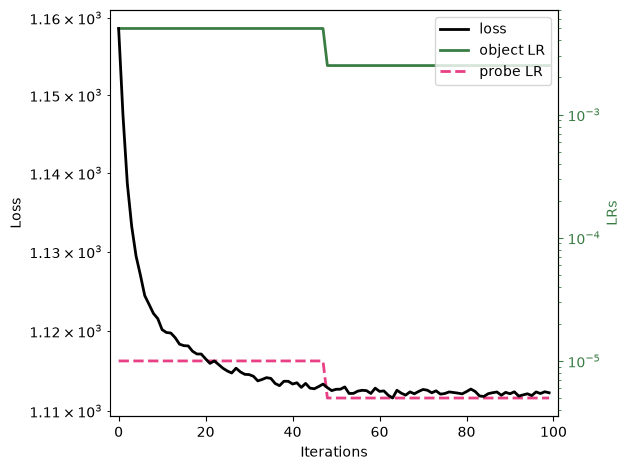

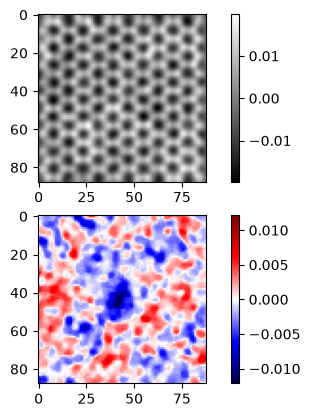

Running with tv_channel_diff=100.0, sparcity=10.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

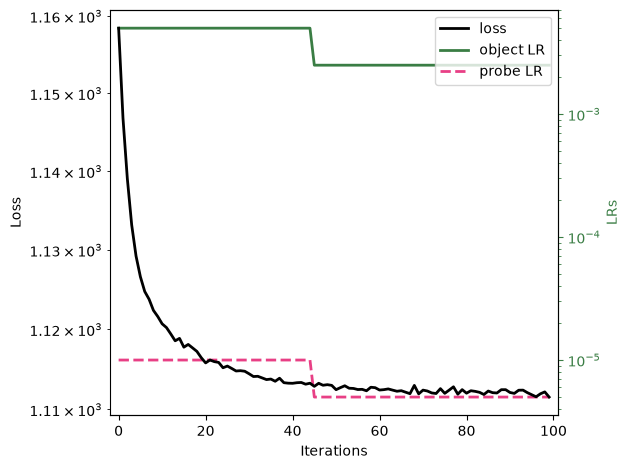

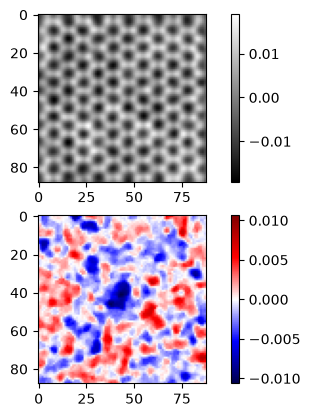

Running with tv_channel_diff=100.0, sparcity=20
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

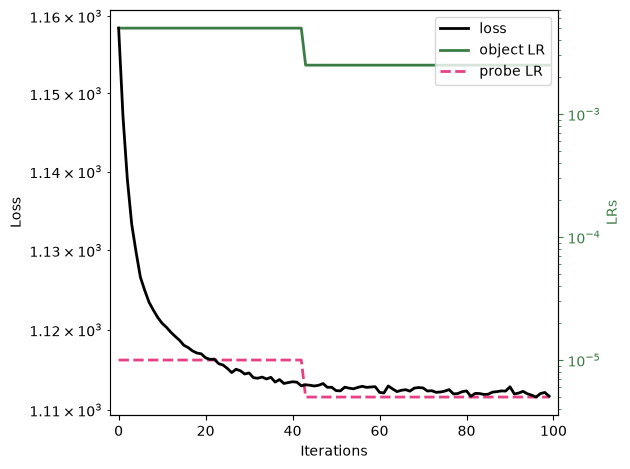

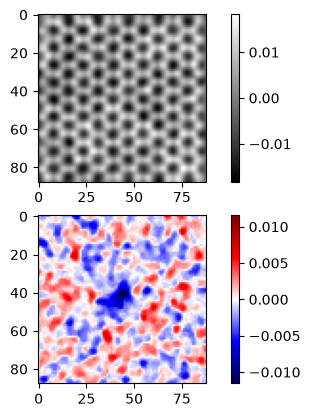

Running with tv_channel_diff=200, sparcity=0.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

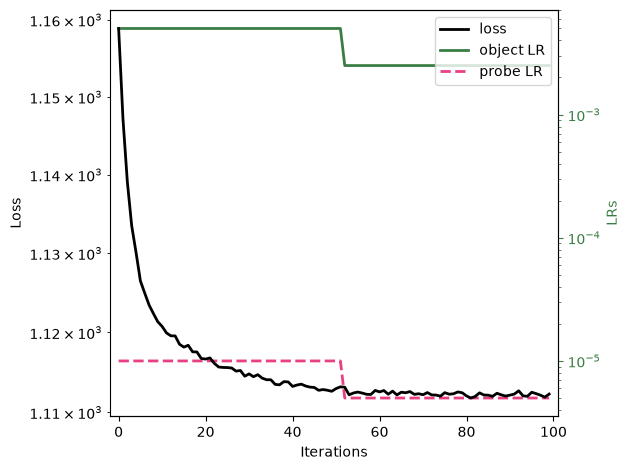

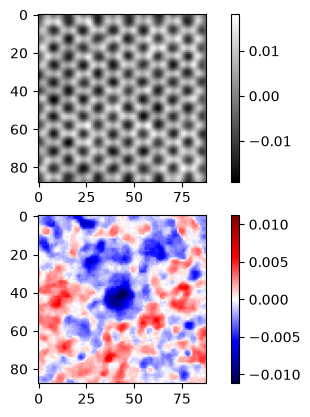

Running with tv_channel_diff=200, sparcity=1.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

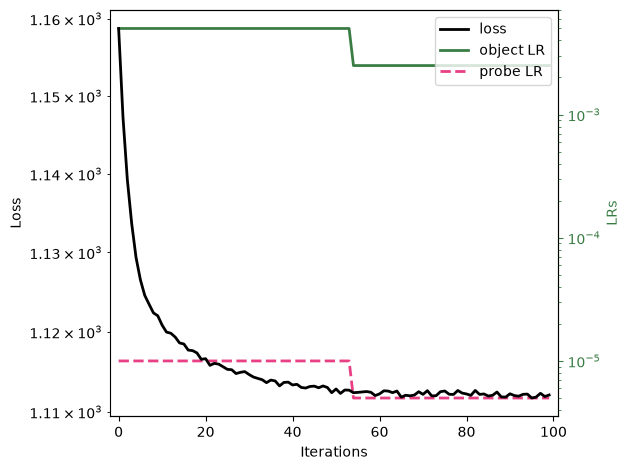

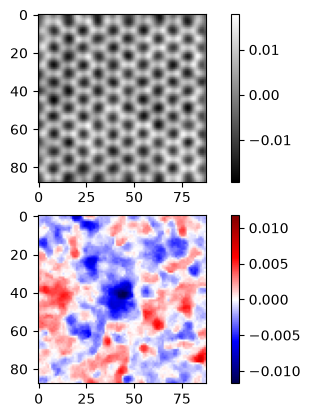

Running with tv_channel_diff=200, sparcity=5.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

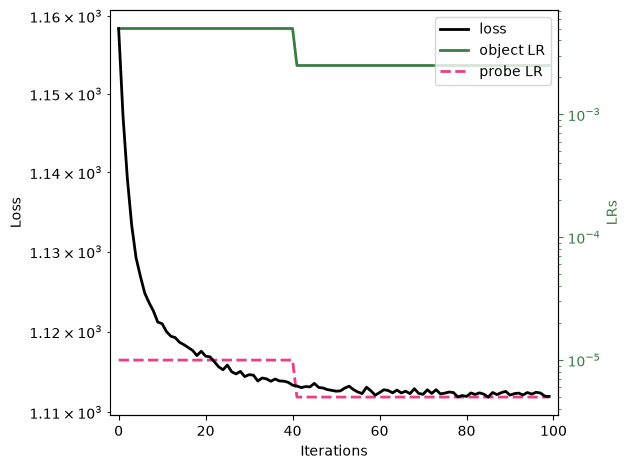

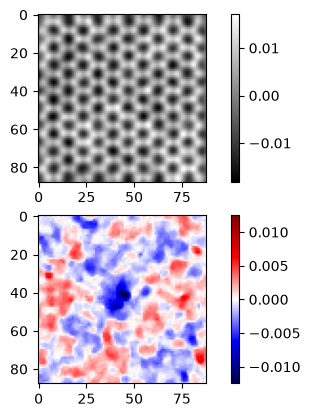

Running with tv_channel_diff=200, sparcity=10.0
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

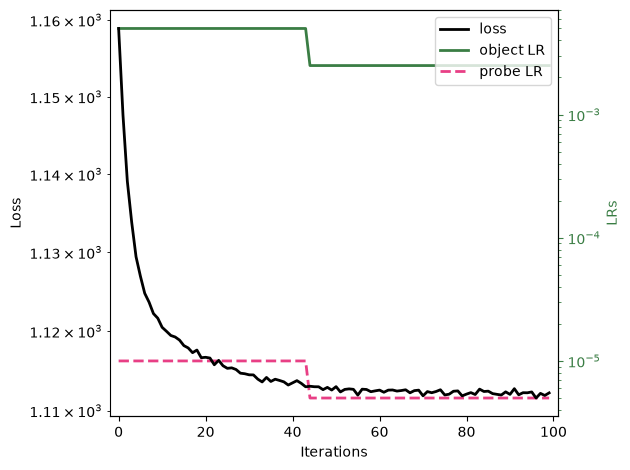

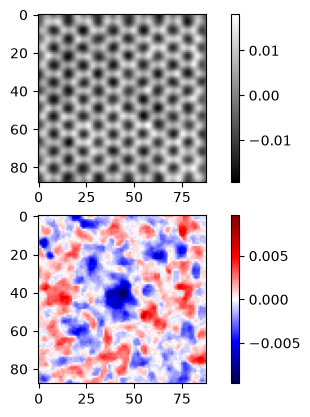

Running with tv_channel_diff=200, sparcity=20
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

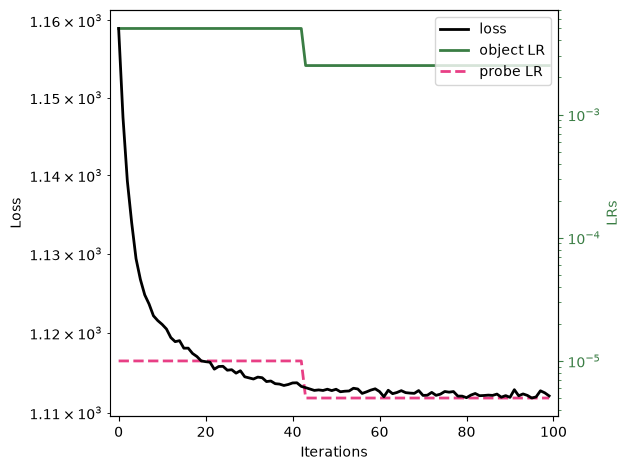

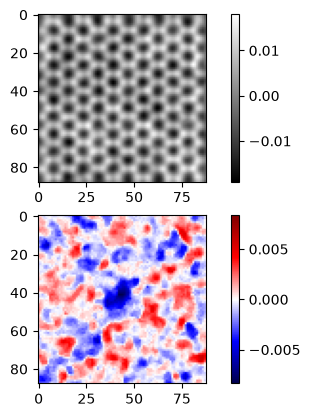

In [ ]:
for tv_channel_diff in [0.0, 100.0, 200, 300, 500]:
    for sparcity in [0.0, 10, 50, 100, 200, 300]:
        print(f"Running with tv_channel_diff={tv_channel_diff}, sparcity={sparcity}")
        recon_off, recon_on, ptycho = mixed_obj_ptycho_wrapper(
            dcube=scan,
            scan_mask=scan_mask,
            num_iters=100,
            tv_channel_diff=tv_channel_diff,
            tv_weight=0,
            channel_diff_sparcity=sparcity,
            obj_lr=5e-3,
            return_extra=True,
            batch_size=2**12,
            obj_padding=64
        )
